In [10]:
!ls /kaggle/input/datasets/mithilesh2303

new-top5-dataset


In [2]:
import os

DATASET_ROOT = "/kaggle/input/datasets/mithilesh2303/new-top5-dataset/content/new_top5_dataset"

print("Dataset folders:", os.listdir(DATASET_ROOT))

Dataset folders: ['val', 'test', 'train']


In [3]:
import json
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

NUM_CLASSES = 5

Device: cuda


In [4]:
CATEGORY_MAP = {
    1:0,   # short sleeve top
    2:1,   # long sleeve top
    7:2,   # shorts
    8:3,   # trousers
    9:4    # skirt
}

def build_label(annotation):

    label = torch.zeros(NUM_CLASSES)

    for k in annotation:
        if k.startswith("item"):
            cid = annotation[k]["category_id"]

            if cid in CATEGORY_MAP:
                label[CATEGORY_MAP[cid]] = 1

    return label

In [5]:
class ClothingDataset(Dataset):

    def __init__(self,img_dir,ann_dir,transform):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.files = os.listdir(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self,idx):

        img_name = self.files[idx]

        img_path = os.path.join(self.img_dir,img_name)
        ann_path = os.path.join(self.ann_dir,img_name.replace(".jpg",".json"))

        image = Image.open(img_path).convert("RGB")

        with open(ann_path) as f:
            ann = json.load(f)

        label = build_label(ann)

        return self.transform(image), label

In [6]:
transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [7]:
# ── Data Augmentation ────────────────────────────────────────────────────────
train_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.RandomRotation(degrees=15),
    T.RandomPerspective(distortion_scale=0.2, p=0.3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

val_test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
train_dataset = ClothingDataset(
    os.path.join(DATASET_ROOT,"train","images"),
    os.path.join(DATASET_ROOT,"train","annotations"),
    train_transform
)
val_dataset = ClothingDataset(
    os.path.join(DATASET_ROOT,"val","images"),
    os.path.join(DATASET_ROOT,"val","annotations"),
    val_test_transform
)
test_dataset = ClothingDataset(
    os.path.join(DATASET_ROOT,"test","images"),
    os.path.join(DATASET_ROOT,"test","annotations"),
    val_test_transform
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 100921
Val size: 21626
Test size: 21627


In [17]:
from torch.utils.data import Subset
import random

subset_size = int(0.5 * len(train_dataset))

indices = random.sample(range(len(train_dataset)), subset_size)

train_dataset = Subset(train_dataset, indices)

print("Subset train size:", len(train_dataset))

Subset train size: 50460


In [9]:
class_names = [
    "short_sleeve_top",
    "long_sleeve_top",
    "shorts",
    "trousers",
    "skirt"
]
# ── Class Balancing ───────────────────────────────────────────────────────────
import numpy as np
from torch.utils.data import WeightedRandomSampler

print("Collecting training labels from annotation files ...")

ann_dir = os.path.join(DATASET_ROOT, "train", "annotations")

if hasattr(train_dataset, "indices"):   # it's a Subset
    files = [train_dataset.dataset.files[i] for i in train_dataset.indices]
else:
    files = train_dataset.files

all_train_labels = []
for img_name in files:
    ann_path = os.path.join(ann_dir, img_name.replace(".jpg", ".json"))
    with open(ann_path) as f:
        ann = json.load(f)
    all_train_labels.append(build_label(ann).numpy())

all_train_labels = np.array(all_train_labels)
print(f"Labels collected: {all_train_labels.shape}")

# pos_weight for BCEWithLogitsLoss
pos_counts = all_train_labels.sum(axis=0)
neg_counts = len(all_train_labels) - pos_counts
pos_weight = neg_counts / np.clip(pos_counts, 1, None)
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(device)

print(f"Class names : {class_names}")
print(f"Pos counts  : {pos_counts.astype(int)}")
print(f"Neg counts  : {neg_counts.astype(int)}")
print(f"pos_weight  : {np.round(pos_weight, 2)}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
print("Criterion updated with pos_weight.")

# WeightedRandomSampler
class_freq = pos_counts / len(all_train_labels)
inv_freq   = 1.0 / np.clip(class_freq, 1e-6, None)

sample_weights = []
for lbl in all_train_labels:
    active = lbl.astype(bool)
    w = inv_freq[active].mean() if active.any() else inv_freq.min()
    sample_weights.append(w)

sample_weights = torch.tensor(sample_weights, dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler,
    num_workers=4,
    pin_memory=True
)
print(f"train_loader rebuilt with WeightedRandomSampler ({len(sampler)} samples/epoch).")

Labels collected: (100921, 5)
Class names : ['short_sleeve_top', 'long_sleeve_top', 'shorts', 'trousers', 'skirt']
Pos counts  : [49410 25024 25486 38576 21382]
Neg counts  : [51511 75897 75435 62345 79539]
pos_weight  : [1.04 3.03 2.96 1.62 3.72]
Criterion updated with pos_weight.
train_loader rebuilt with WeightedRandomSampler (100921 samples/epoch).


In [11]:
import torchvision.models as models

model = models.efficientnet_b0(weights="DEFAULT")

for param in model.features.parameters():
    param.requires_grad = False

for param in model.features[-2:].parameters():
    param.requires_grad = True

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)

model = model.to(device)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [12]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

EPOCHS = 10

In [13]:
from tqdm import tqdm

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    loop = tqdm(train_loader)

    for images,labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images,labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs,labels)

            val_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Val Loss: {val_loss/len(val_loader):.4f}"
    )

Epoch [1/10]: 100%|██████████| 6308/6308 [11:58<00:00,  8.78it/s, loss=0.495]


Epoch 1/10 | Train Loss: 0.4812 | Val Loss: 0.3695


Epoch [2/10]: 100%|██████████| 6308/6308 [10:30<00:00, 10.01it/s, loss=0.453]


Epoch 2/10 | Train Loss: 0.4290 | Val Loss: 0.3416


Epoch [3/10]: 100%|██████████| 6308/6308 [10:13<00:00, 10.28it/s, loss=0.358]


...

Epoch 8/10 | Train Loss: 0.3552 | Val Loss: 0.2945


Epoch [9/10]: 100%|██████████| 6308/6308 [09:49<00:00, 10.70it/s, loss=0.189]


Epoch 9/10 | Train Loss: 0.3487 | Val Loss: 0.2885


Epoch [10/10]: 100%|██████████| 6308/6308 [09:51<00:00, 10.66it/s, loss=0.318]


Epoch 10/10 | Train Loss: 0.3415 | Val Loss: 0.2864


In [15]:
import numpy as np

model.eval()

all_preds = []
all_targets = []

with torch.no_grad():

    for images,labels in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        all_preds.append(probs.cpu())
        all_targets.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

y_pred = (all_preds > 0.5).astype(int)
y_true = all_targets

100%|██████████| 676/676 [05:37<00:00,  2.00it/s]


In [16]:
from sklearn.metrics import classification_report

class_names = [
    "short_sleeve_top",
    "long_sleeve_top",
    "shorts",
    "trousers",
    "skirt"
]

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

                  precision    recall  f1-score   support

short_sleeve_top       0.80      0.79      0.80     10588
 long_sleeve_top       0.74      0.62      0.67      5370
          shorts       0.84      0.76      0.80      5380
        trousers       0.93      0.86      0.89      8201
           skirt       0.73      0.72      0.72      4569

       micro avg       0.82      0.76      0.79     34108
       macro avg       0.81      0.75      0.78     34108
    weighted avg       0.82      0.76      0.79     34108
     samples avg       0.78      0.77      0.76     34108



In [17]:
from sklearn.metrics import f1_score

micro_f1 = f1_score(y_true,y_pred,average="micro")
macro_f1 = f1_score(y_true,y_pred,average="macro")

print("Micro F1:",micro_f1)
print("Macro F1:",macro_f1)

Micro F1: 0.7911690521773482
Macro F1: 0.7768492612081619


In [18]:
from collections import Counter

counter = Counter()
test_annotation_dir = os.path.join(DATASET_ROOT, "test", "annotations")
for file in os.listdir(test_annotation_dir):
    with open(os.path.join(test_annotation_dir, file)) as f:
        data = json.load(f)

    for k in data:
        if k.startswith("item"):
            counter[data[k]["category_id"]] += 1

print(counter)

Counter({1: 10740, 8: 8256, 7: 5422, 2: 5419, 9: 4606})


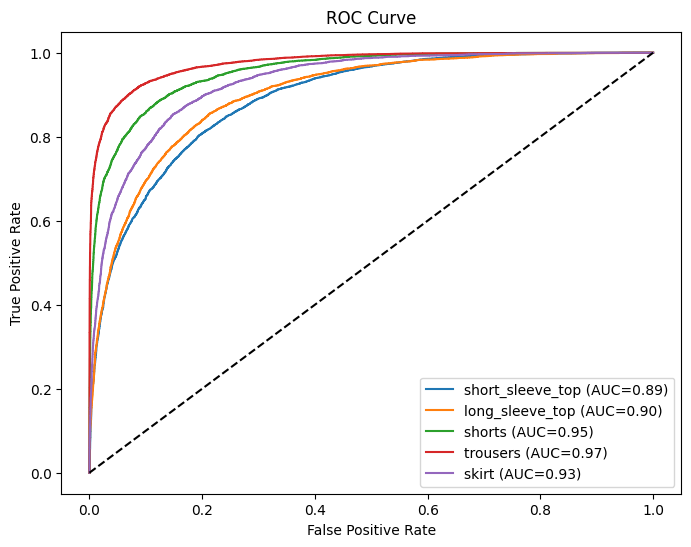

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i in range(NUM_CLASSES):

    fpr,tpr,_ = roc_curve(y_true[:,i],all_preds[:,i])
    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [20]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(y_true,all_preds,average="macro")
micro_auc = roc_auc_score(y_true,all_preds,average="micro")

print("Macro AUC:",macro_auc)
print("Micro AUC:",micro_auc)

Macro AUC: 0.9300107477867765
Micro AUC: 0.9388609383231497


In [22]:
# Save model in Kaggle working directory
model_path = "/kaggle/working/efficientnet_finetuned.pth"

torch.save(model.state_dict(), model_path)

print("Model saved:", model_path)

Model saved: /kaggle/working/efficientnet_finetuned.pth


                  precision    recall  f1-score   support

short_sleeve_top       0.80      0.79      0.80     10588
 long_sleeve_top       0.74      0.62      0.67      5370
          shorts       0.84      0.76      0.80      5380
        trousers       0.93      0.86      0.89      8201
           skirt       0.73      0.72      0.72      4569

       micro avg       0.82      0.76      0.79     34108
       macro avg       0.81      0.75      0.78     34108
    weighted avg       0.82      0.76      0.79     34108
     samples avg       0.78      0.77      0.76     34108

Micro F1: 0.7912 | Macro F1: 0.7768
Micro AUC: 0.9389 | Macro AUC: 0.9300


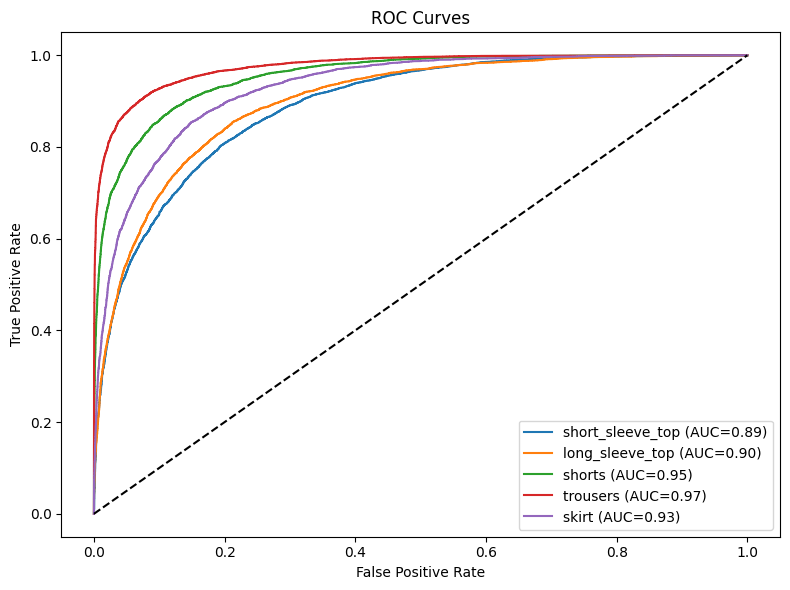

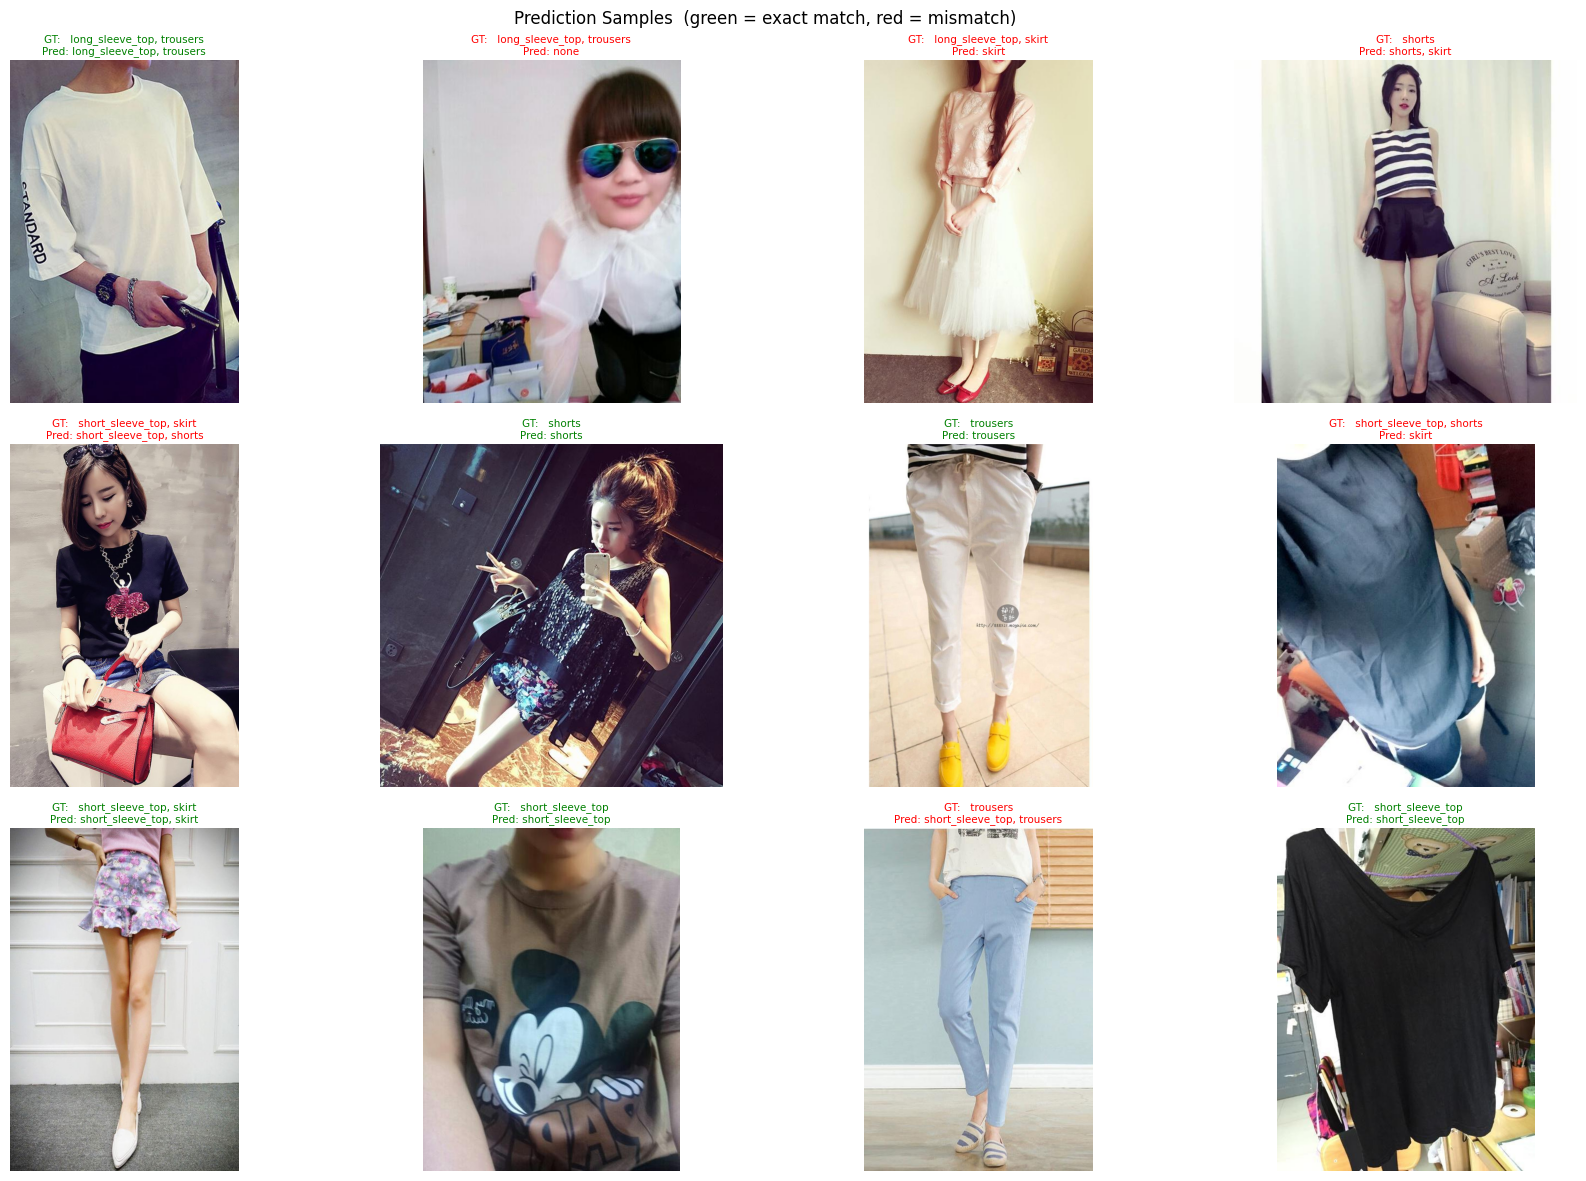


All outputs saved to: /kaggle/working/results
['efficientnet_scratch.pth', 'summary_metrics.txt', 'roc_curves.png', 'efficientnet_finetuned.pth', 'classification_report.txt', 'prediction_samples.png']


In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, json, random, torch
import numpy as np
from PIL import Image

SAVE_DIR = "/kaggle/working/results"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. Save metrics ───────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, f1_score, roc_auc_score

report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
with open(os.path.join(SAVE_DIR, "classification_report.txt"), "w") as f:
    f.write(report)
print(report)

micro_f1 = f1_score(y_true, y_pred, average="micro")
macro_f1 = f1_score(y_true, y_pred, average="macro")
macro_auc = roc_auc_score(y_true, all_preds, average="macro")
micro_auc = roc_auc_score(y_true, all_preds, average="micro")

with open(os.path.join(SAVE_DIR, "summary_metrics.txt"), "w") as f:
    f.write(f"Micro F1  : {micro_f1:.4f}\n")
    f.write(f"Macro F1  : {macro_f1:.4f}\n")
    f.write(f"Micro AUC : {micro_auc:.4f}\n")
    f.write(f"Macro AUC : {macro_auc:.4f}\n")
print(f"Micro F1: {micro_f1:.4f} | Macro F1: {macro_f1:.4f}")
print(f"Micro AUC: {micro_auc:.4f} | Macro AUC: {macro_auc:.4f}")

# ── 2. ROC curve ──────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true[:, i], all_preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "roc_curves.png"), dpi=150)
plt.show()

# ── 3. Prediction plots ───────────────────────────────────────────────────────
# Pick 12 random test images and show ground truth vs predicted labels
test_img_dir = os.path.join(DATASET_ROOT, "test", "images")
test_ann_dir = os.path.join(DATASET_ROOT, "test", "annotations")
test_files   = os.listdir(test_img_dir)

sample_files = random.sample(test_files, 12)

model.eval()
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, img_name in zip(axes, sample_files):
    # Load and preprocess
    img_path = os.path.join(test_img_dir, img_name)
    ann_path = os.path.join(test_ann_dir, img_name.replace(".jpg", ".json"))

    image = Image.open(img_path).convert("RGB")
    with open(ann_path) as f:
        ann = json.load(f)

    gt_label = build_label(ann).numpy().astype(int)

    inp = val_test_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(inp)).cpu().numpy()[0]
    pred_label = (prob > 0.5).astype(int)

    # Build title lines
    gt_str   = ", ".join([class_names[i] for i in range(NUM_CLASSES) if gt_label[i]])   or "none"
    pred_str = ", ".join([class_names[i] for i in range(NUM_CLASSES) if pred_label[i]]) or "none"
    correct  = np.array_equal(gt_label, pred_label)

    ax.imshow(image)
    ax.axis("off")
    ax.set_title(
        f"GT:   {gt_str}\nPred: {pred_str}",
        fontsize=7.5,
        color="green" if correct else "red",
        pad=4
    )

plt.suptitle("Prediction Samples  (green = exact match, red = mismatch)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "prediction_samples.png"), dpi=150)
plt.show()

# ── 4. Save model ─────────────────────────────────────────────────────────────
torch.save(model.state_dict(), os.path.join(SAVE_DIR, "efficientnet_finetuned.pth"))
print(f"\nAll outputs saved to: {SAVE_DIR}")
print(os.listdir(SAVE_DIR))

In [ ]:
!zip -r /kaggle/working/results.zip /kaggle/working/results